# LAB-2: Predicting Wine Quality using KNN, RF, MLP and Comparing the results


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Load Wine Quality Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')


# Creating Target Variable

In [3]:
df['quality_label'] = (df['quality'] >= 7).astype(int)

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


# Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# KNN Model with Pipeline & GridSearch

In [7]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7]
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5)
knn_grid.fit(X_train, y_train)

knn_pred = knn_grid.predict(X_test)


# Random Forest Classifier

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


# MLP Neural Network

In [13]:

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

MLPClassifier(
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

mlp_pipeline.fit(X_train, y_train)
mlp_pred = mlp_pipeline.predict(X_test)


# Model Evaluation Function

In [14]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))


# Evaluate All Models

In [15]:
evaluate_model("KNN", y_test, knn_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("MLP", y_test, mlp_pred)



KNN
Accuracy : 0.890625
Precision: 0.6428571428571429
Recall   : 0.4186046511627907
F1 Score : 0.5070422535211268

Random Forest
Accuracy : 0.94375
Precision: 0.9310344827586207
Recall   : 0.627906976744186
F1 Score : 0.75

MLP
Accuracy : 0.91875
Precision: 0.717948717948718
Recall   : 0.6511627906976745
F1 Score : 0.6829268292682927


# Bar Graph 


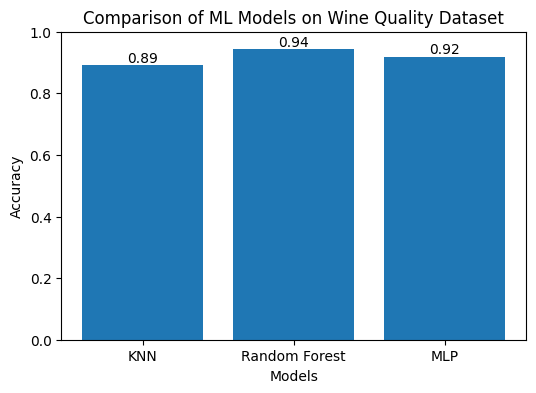

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models on Wine Quality Dataset")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


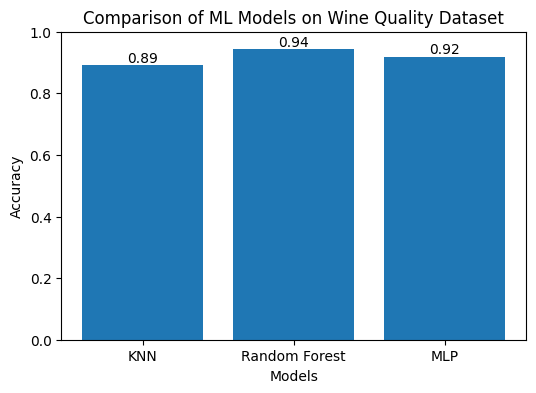

In [19]:
plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models on Wine Quality Dataset")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


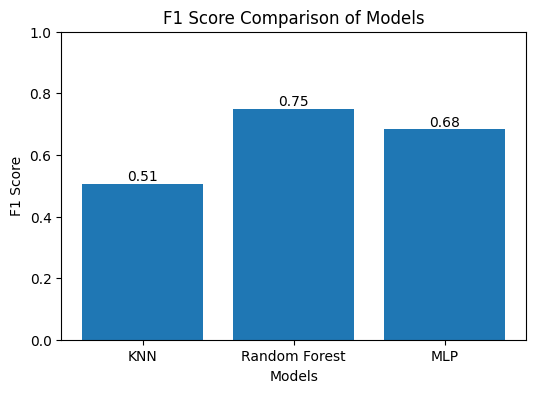

In [20]:
f1_scores = [
    f1_score(y_test, knn_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, mlp_pred)
]

plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Models")
plt.ylim(0, 1)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


In [21]:
models = ['KNN', 'Random Forest', 'MLP']

accuracy = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, mlp_pred)
]

precision = [
    precision_score(y_test, knn_pred),
    precision_score(y_test, rf_pred),
    precision_score(y_test, mlp_pred)
]

recall = [
    recall_score(y_test, knn_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, mlp_pred)
]

f1 = [
    f1_score(y_test, knn_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, mlp_pred)
]


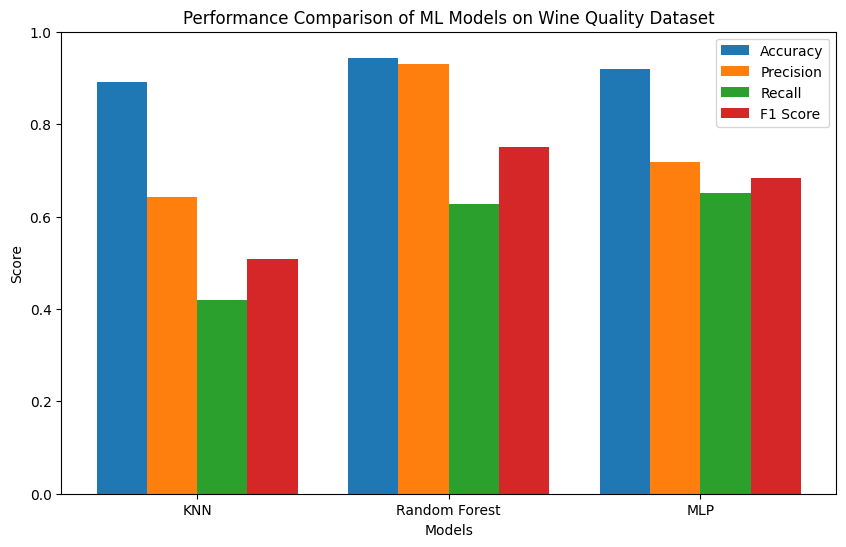

In [22]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xlabel("Models")
plt.title("Performance Comparison of ML Models on Wine Quality Dataset")
plt.legend()

plt.show()


# Confusion Matrix Visualization

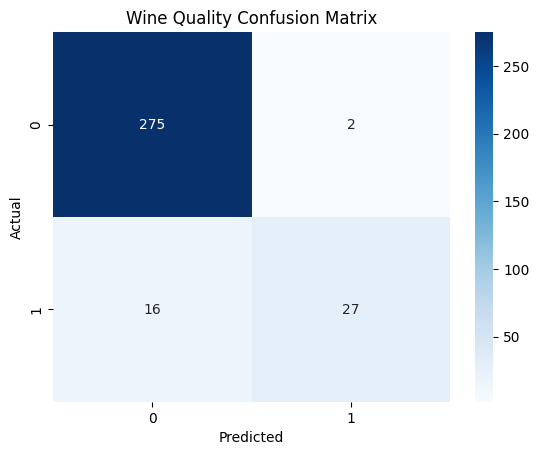

In [16]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Wine Quality Confusion Matrix")
plt.show()
